In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import os
import re
from pathlib import Path
from typing import List, Tuple

import numpy as np
np.seterr(all='ignore')
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed

import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL
import function_future.date_selection as DS
import function_future.trading_visualization as TV
from function_future.margin_calculator import calculate_margin, get_instrument_info, get_first_trade_date, get_recent_activity

In [3]:
symbol_lst = ["A", "B", "C", "CS", "M", "Y", "P", "LH"]

In [4]:
init_money_lst = []
for symbol in symbol_lst:
    margin = calculate_margin(symbol, 10)
    info = get_instrument_info(symbol)
    first_date = get_first_trade_date(symbol)
    activity = get_recent_activity(symbol)
    print(f"\n品种: {symbol} ({info.get('name', 'N/A')})")
    print(f"  首个交易日: {first_date}")
    print(f"  95分位数价格: {info['price_95th']:.2f}")
    print(f"  合约乘数: {info['contract_multiplier']}")
    print(f"  保证金率: {info['margin_rate']:.2%}")
    print(f"  10手保证金: {margin:,.2f}")
    print(f"  40%保证金所需本金: {margin / 0.4:,.0f} ")
    # print(f"  交易所: {info['exchange']}")
    print(f"  分均持仓量: {activity['avg_open_interest']:,.0f}")
    print(f"  分均成交量: {activity['avg_volume']:,.0f}")
    print(f"  分均成交额: {activity['avg_turnover']:,.0f}")

    init_money_lst.append(int(margin / 0.4))


品种: A (豆一)
  首个交易日: 2021-02-02
  95分位数价格: 4716.00
  合约乘数: 10
  保证金率: 7.00%
  10手保证金: 33,012.00
  40%保证金所需本金: 82,530 
  分均持仓量: 200,917
  分均成交量: 410
  分均成交额: 17,508,103

品种: B (豆二)
  首个交易日: 2021-02-02
  95分位数价格: 3800.00
  合约乘数: 10
  保证金率: 7.00%
  10手保证金: 26,600.00
  40%保证金所需本金: 66,500 
  分均持仓量: 128,862
  分均成交量: 364
  分均成交额: 13,179,785

品种: C (玉米)
  首个交易日: 2021-02-02
  95分位数价格: 2381.00
  合约乘数: 10
  保证金率: 7.00%
  10手保证金: 16,667.00
  40%保证金所需本金: 41,668 
  分均持仓量: 1,017,181
  分均成交量: 1,483
  分均成交额: 33,631,985

品种: CS (玉米淀粉)
  首个交易日: 2021-02-02
  95分位数价格: 2729.00
  合约乘数: 10
  保证金率: 6.00%
  10手保证金: 16,374.00
  40%保证金所需本金: 40,935 
  分均持仓量: 192,842
  分均成交量: 319
  分均成交额: 8,245,518

品种: M (豆粕)
  首个交易日: 2021-02-02
  95分位数价格: 3100.00
  合约乘数: 10
  保证金率: 7.00%
  10手保证金: 21,700.00
  40%保证金所需本金: 54,250 
  分均持仓量: 2,024,162
  分均成交量: 3,175
  分均成交额: 94,125,469

品种: Y (豆油)
  首个交易日: 2021-02-02
  95分位数价格: 8636.00
  合约乘数: 10
  保证金率: 7.00%
  10手保证金: 60,452.00
  40%保证金所需本金: 151,130 
  分均持仓量: 586,120
  分均成交量: 897
 

In [5]:
initial_capital = dict(zip(symbol_lst, init_money_lst))
initial_capital

{'A': 82530,
 'B': 66500,
 'C': 41667,
 'CS': 40934,
 'M': 54250,
 'Y': 151130,
 'P': 194960,
 'LH': 459520}

In [6]:
weights = dict(zip(symbol_lst, [5_000_000 // x for x in init_money_lst]))
weights

{'A': 60, 'B': 75, 'C': 119, 'CS': 122, 'M': 92, 'Y': 33, 'P': 25, 'LH': 10}

In [7]:
train_label = 5
rtn_mul = 1

bt_params = (0.9, 0.5, 10, 5*465)
train_end_date = '2025-01-01'

In [8]:
def run_res(symbol, bt_params):
    folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

    config_loader = DL.InstrumentConfig()
    config_loader.get_instrument_config(symbol)

    config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
    config['MODEL_DIR'] = f'/home/strategy_res/multi_train/models/{"_".join(symbol_lst)}'

    bt = bv.ModelBacktester(train_end_date, config)
    bt.load_config(symbol)
    bt.window_end = '2027-01-01'
    bt.money = initial_capital[symbol]
    bt.fee = 0

    # bt.load_factor(symbol, end_date=bt.window_end)

    factor_single = pd.read_feather(f'/home/strategy_res/multi_train/merged_df/{"_".join(symbol_lst)}.feather')
    factor_single = factor_single[factor_single['symbol'] == symbol].reset_index(drop=True)
    factor_single['hour'] = factor_single.datetime.dt.hour
    factor_single = factor_single[factor_single.datetime >= train_end_date]
    # factor_single = factor_single[factor_single.datetime.astype('datetime64[ns]').between(start_date, end_date)]
    
    factor_single = factor_single.sort_values('datetime').drop_duplicates('datetime', keep='last')
    factor_single = factor_single[~((factor_single['datetime'].dt.hour == 10) & (factor_single['datetime'].dt.minute == 30))]
    factor_single['datetime'] = pd.to_datetime(factor_single.datetime)
    bt.factor_single = factor_single.round(8) 

    bt.load_mktdata(symbol, end_date=bt.window_end)
    bt.load_models()
    bt.generate_predictions()
    pred = bt.combine_models('best_iteration_log_weighted', avg=True)

    th1, th2, holding_bars, day = bt_params
    merged_data = bt.backtest(th1=th1, th2=th2, save=False, open_drop=True, holding_bars=holding_bars,
                           day=day, model_name='best_iteration_log_weighted', v=2
                        )

    return merged_data

In [9]:
merged_data_lst = []
for symbol in symbol_lst:
    print(f"\nProcessing {symbol}...")
    merged_data = run_res(symbol, bt_params)
    merged_data_lst.append(merged_data)


Processing A...
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


  0%|          | 0/91068 [00:00<?, ?it/s]


Processing B...
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


  0%|          | 0/84903 [00:00<?, ?it/s]


Processing C...
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


...

  0%|          | 0/91068 [00:00<?, ?it/s]


Processing P...
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


  0%|          | 0/91068 [00:00<?, ?it/s]


Processing LH...
trading_hours ['09:00-11:30', '13:30-15:00']


  0%|          | 0/57375 [00:00<?, ?it/s]

In [10]:
# merged_data_lst = Parallel(n_jobs=1)(delayed(run_res)(symbol, bt_params)
#                                                    for symbol in symbol_lst)

In [11]:
def plot_all(symbol_lst, merged_data_lst, weights=None):
    pnl_ret = []
    for i, merged_data in enumerate(merged_data_lst):
        symbol = symbol_lst[i]
        df = merged_data.set_index('datetime')[['equity', 'date']]
        df.rename(columns={'equity':symbol}, inplace=True)
        df = df.groupby('date').last()
        # 如果有权重配置，应用权重
        if weights and symbol in weights:
            df[symbol] = df[symbol] * weights[symbol]

        pnl_ret.append(df)

    return pd.concat(pnl_ret,axis=1).ffill().iloc[:-20]

In [12]:
merged_df_all = plot_all(symbol_lst, merged_data_lst, weights=weights)
merged_df_all

,A,B,C,CS,M,Y,P,LH
date,,,,,,,,
2025-01-02,5.002407e+06,5.257085e+06,5.036095e+06,5.059878e+06,5.032108e+06,5.158474e+06,5.115921e+06,4.603614e+06
2025-01-03,5.037790e+06,5.123581e+06,4.859778e+06,5.071582e+06,5.279501e+06,5.073059e+06,5.004793e+06,4.862774e+06
2025-01-06,5.019388e+06,5.251712e+06,4.993997e+06,5.192635e+06,5.508021e+06,5.146007e+06,4.935491e+06,4.864720e+06
2025-01-07,5.034916e+06,5.504092e+06,5.152903e+06,5.278057e+06,5.861839e+06,5.239061e+06,4.976808e+06,5.291461e+06
2025-01-08,5.102631e+06,5.430588e+06,5.213757e+06,5.279898e+06,5.863122e+06,5.235616e+06,4.967157e+06,5.230125e+06
...,...,...,...,...,...,...,...,...
2026-03-04,1.145248e+07,1.431082e+07,1.782613e+07,1.349049e+07,1.100265e+07,9.376208e+06,1.138869e+07,1.204377e+07
2026-03-05,1.159601e+07,1.424696e+07,1.793002e+07,1.367031e+07,1.108217e+07,9.652424e+06,1.148155e+07,1.202510e+07
2026-03-06,1.146045e+07,1.386215e+07,1.789172e+07,1.358051e+07,1.052676e+07,9.785152e+06,1.110497e+07,1.209942e+07


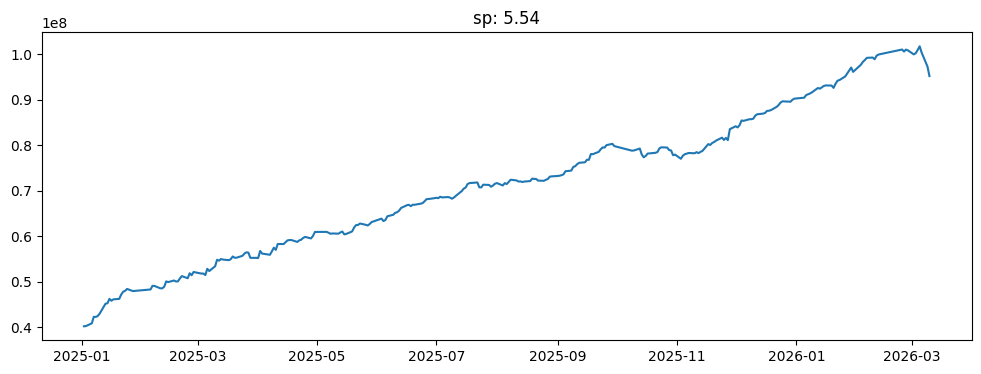

In [13]:
sp = merged_df_all.sum(axis=1).diff().mean() / merged_df_all.sum(axis=1).diff().std() * np.sqrt(252)
plt.figure(figsize=(12, 4))  # Correct way to set figure size
plt.plot(merged_df_all.sum(axis=1))
plt.title(f'sp: {round(sp,2)}')
plt.show()

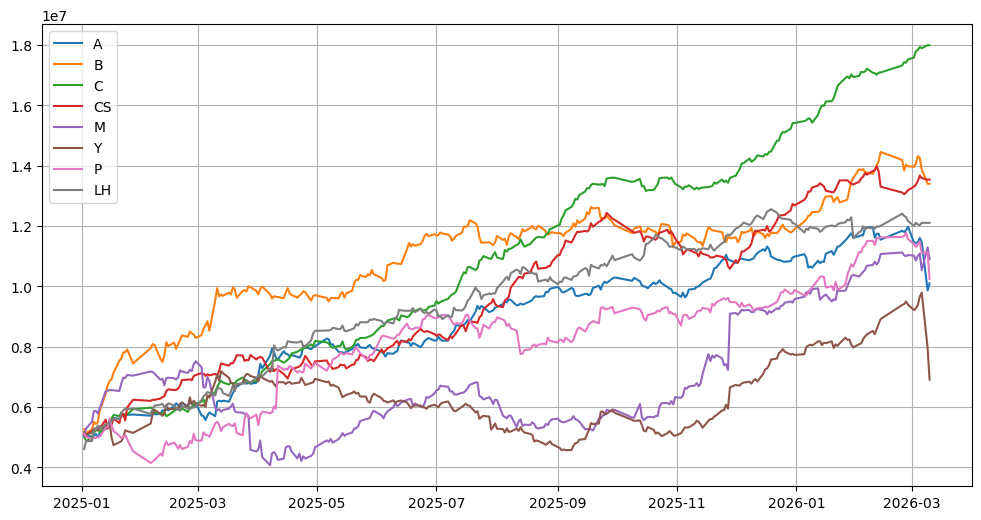

In [14]:
fig = plt.figure(figsize=(12, 6))
plt.plot(merged_df_all)
plt.legend(symbol_lst)
plt.grid()
plt.show()

In [15]:
res = pd.concat((bv.analyze_pos_distribution(merged_data_lst[i]) for i in range(len(symbol_lst))), axis=1)
res.columns = symbol_lst
res

,A,B,C,CS,M,Y,P,LH
多头(+1) 数量,19296,17647,18331,18704,18895,18447,17915,11112
空头(-1) 数量,18824,19191,16995,18052,19205,18549,17297,11839
空仓(0) 数量,52950,48067,49579,48149,52970,54074,55858,34426
多头占比,21.19%,20.78%,21.59%,22.03%,20.75%,20.26%,19.67%,19.37%
空头占比,20.67%,22.60%,20.02%,21.26%,21.09%,20.37%,18.99%,20.63%
空仓占比,58.14%,56.61%,58.39%,56.71%,58.16%,59.38%,61.34%,60.00%
交易日数量,305,284,284,284,305,305,305,282
总收益(非年化%),144.45,168.44,263.11,173.66,124.04,12.87,51.63,163.31
总交易次数（开平算一次）,5428,4311,6422,5860,5247,4598,3668,2636
日均交易次数（开平算一次）,17.80,15.18,22.61,20.63,17.20,15.08,12.02,9.35
